In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [18]:
def load_and_prepare(filename):
    """
    Load a stock CSV, clean it, compute log-returns and
    60-day realized volatility (annualized).
    Returns a DataFrame with columns: Date, LogRet, RV
    """

    # ---- 1.1 Read the CSV ----
    df = pd.read_csv(filename)
    print(f"Loaded {filename}, shape = {df.shape}")

    # Some providers use 'Close*' instead of 'Close'
    if "Close*" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Close*": "Close"})

    # ---- 1.2 Convert Date to datetime ----
    # If this format fails, remove "format=..." and let pandas guess.
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

    # ---- 1.3 Clean Close prices (remove commas, convert to float) ----
    df["Close"] = (
        df["Close"]
        .astype(str)                # make sure it's string
        .str.replace(",", "")       # remove thousands commas: "5,881.63" -> "5881.63"
    )
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # ---- 1.4 Sort by Date ----
    df = df.sort_values("Date")

    # ---- 1.5 Compute daily log-returns ----
    df["LogRet"] = np.log(df["Close"] / df["Close"].shift(1))

    # ---- 1.6 Compute 60-day rolling realized volatility (annualized) ----
    df["RV"] = df["LogRet"].rolling(window=60).std() * np.sqrt(252)

    # ---- 1.7 Keep only what we need ----
    return df[["Date", "LogRet", "RV"]]

In [19]:
# 2. Load and prepare ALL FOUR FILES
# ============================================================
aapl = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv')
nvda = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv')
tsla = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv')
spx  = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv')

# Rename columns so we know which series is which after merging
aapl = aapl.rename(columns={"LogRet": "RET_AAPL", "RV": "RV_AAPL"})
nvda = nvda.rename(columns={"LogRet": "RET_NVDA", "RV": "RV_NVDA"})
tsla = tsla.rename(columns={"LogRet": "RET_TSLA", "RV": "RV_TSLA"})
spx  = spx.rename(columns={"LogRet": "RET_SPX",  "RV": "RV_SPX"})

Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv, shape = (3651, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv, shape = (3774, 7)


In [20]:
# ============================================================
# 3. Merge all four on Date into one DataFrame
# ============================================================
data = (
    spx.merge(aapl, on="Date")
       .merge(nvda, on="Date")
       .merge(tsla, on="Date")
)

# Drop rows with NaN from rolling calculations
data = data.dropna().reset_index(drop=True)

print("\nMerged data shape:", data.shape)
print(data.head())


Merged data shape: (3591, 9)
        Date   RET_SPX    RV_SPX  RET_AAPL   RV_AAPL  RET_NVDA   RV_NVDA  \
0 2010-09-24  0.021026  0.185841  0.011561  0.223556  0.066691  0.592495   
1 2010-09-27 -0.005675  0.186193 -0.003839  0.221820 -0.032790  0.596982   
2 2010-09-28  0.004804  0.185805 -0.015504  0.224300  0.000000  0.596982   
3 2010-09-29 -0.002617  0.185893  0.001951  0.224124  0.000000  0.590685   
4 2010-09-30 -0.003062  0.175986 -0.012752  0.212283 -0.033902  0.574910   

   RET_TSLA   RV_TSLA  
0  0.030305  0.750741  
1  0.022141  0.732411  
2  0.042864  0.685378  
3  0.027588  0.574043  
4 -0.077778  0.596875  


In [21]:
# ============================================================
# 4. Benchmark OLS: RV_SPX ~ RV_AAPL + RV_NVDA + RV_TSLA
# ============================================================
y = data["RV_SPX"]                               # dependent variable
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]]     # explanatory vars
X = sm.add_constant(X)                          # add intercept

ols_model = sm.OLS(y, X).fit()

print("\n================ OLS BENCHMARK RESULTS ================")
print(ols_model.summary())


================ OLS BENCHMARK RESULTS ================
                            OLS Regression Results                            
Dep. Variable:                 RV_SPX   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     3591.
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:01:26   Log-Likelihood:                 6336.3
No. Observations:                3591   AIC:                        -1.266e+04
Df Residuals:                    3587   BIC:                        -1.264e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [22]:
# ============================================================
# 5. (Optional) In-sample error metrics
# ============================================================
data["RV_SPX_hat"] = ols_model.fittedvalues
rmse_ols = np.sqrt(np.mean((data["RV_SPX"] - data["RV_SPX_hat"])**2))
mae_ols  = np.mean(np.abs(data["RV_SPX"] - data["RV_SPX_hat"]))

print("\nIn-sample RMSE:", rmse)
print("In-sample MAE :", mae)


In-sample RMSE: 0.031232858341082703
In-sample MAE : 0.025042371561545262


In [23]:
!pip install xgboost

In [24]:
# ============================================================
# 0. Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
# ============================================================
# 1. Prepare features and target
# ============================================================

# Target: S&P 500 realized volatility
y = data["RV_SPX"].values

# Features for XGBoost:
# you can add more features later (returns, lags, etc.)
feature_cols = ["RV_AAPL", "RV_NVDA", "RV_TSLA"]
X = data[feature_cols].values


In [26]:
# ============================================================
# 2. Time-based train / test split (e.g., 80% train, 20% test)
# ============================================================
n = len(data)
train_size = int(n * 0.8)   # 80% of observations for training

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 2872
Test size : 719


In [27]:
# ============================================================
# 3. Define and fit XGBoost model
# ============================================================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
# ============================================================
# 4. Predictions and performance metrics
# ============================================================

# In-sample (train) predictions
y_train_pred = xgb_model.predict(X_train)

# Out-of-sample (test) predictions
y_test_pred = xgb_model.predict(X_test)

# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

# Test metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)

print("\n===== XGBoost Performance =====")
print("Train RMSE:", rmse_train)
print("Train MAE :", mae_train)
print("Train R²  :", r2_train)

print("\nTest RMSE :", rmse_test)
print("Test MAE  :", mae_test)
print("Test R²   :", r2_test)


===== XGBoost Performance =====
Train RMSE: 0.015247300599104271
Train MAE : 0.011036052918220768
Train R²  : 0.9695669063403293

Test RMSE : 0.04191289180351453
Test MAE  : 0.03288419298855142
Test R²   : 0.5026209982017524


Feature importance - RV_AAPL: 0.5950
Feature importance - RV_NVDA: 0.1697
Feature importance - RV_TSLA: 0.2353


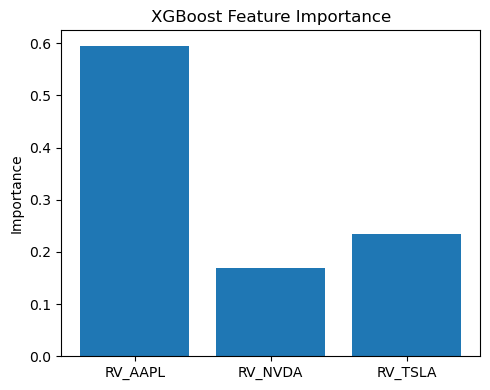

In [29]:
# ============================================================
# 6. Feature importance
# ============================================================

importances = xgb_model.feature_importances_

for col, imp in zip(feature_cols, importances):
    print(f"Feature importance - {col}: {imp:.4f}")

plt.figure(figsize=(5,4))
plt.bar(feature_cols, importances)
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]].values
y = data["RV_SPX"].values

# Train/test split (time-based)
train_size = int(len(data) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# LASSO model
lasso = Lasso(alpha=0.001)   # you can tune alpha
lasso.fit(X_train, y_train)

# Predictions
y_pred = lasso.predict(X_test)

# Metrics
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso  = r2_score(y_test, y_pred)

print("LASSO RMSE:", rmse)
print("LASSO MAE :", mae)
print("LASSO R²  :", r2)

print("Coefficients:", lasso.coef_)


LASSO RMSE: 0.031232858341082703
LASSO MAE : 0.025042371561545262
LASSO R²  : 0.7238050988772405
Coefficients: [0.38698574 0.2032628  0.07034624]



=== Model Performance Comparison ===
                   Model      RMSE       MAE        R²
0        OLS (Benchmark)  0.041443  0.030568  0.750000
1  XGBoost (Selection 1)  0.041913  0.032884  0.502621
2    LASSO (Selection 2)  0.031233  0.025042  0.723805


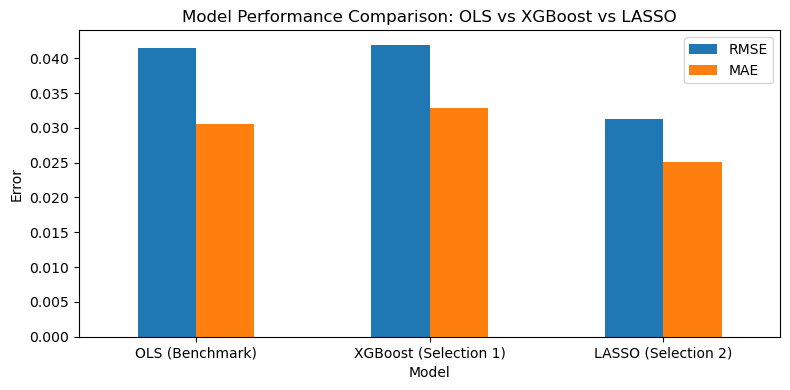

In [31]:
# ============================================================
# Model Performance Comparison Table
# ============================================================

comparison = pd.DataFrame({
    "Model": ["OLS (Benchmark)", "XGBoost (Selection 1)", "LASSO (Selection 2)"],
    "RMSE": [rmse_ols, rmse_test, rmse_lasso],
    "MAE":  [mae_ols, mae_test, mae_lasso],
    "R²":   [0.75, r2_test, r2_lasso]   # OLS R² from summary
})

print("\n=== Model Performance Comparison ===")
print(comparison)

# Optional: visualize RMSE & MAE
comparison.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(8,4))
plt.title("Model Performance Comparison: OLS vs XGBoost vs LASSO")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()